# Content

This code implements a Convolutional Neural Network (CNN) using Keras to classify images from the Fashion MNIST dataset into 10 categories (e.g., T-shirt, Trouser, etc.). Key steps include:  

1. **Data Preparation**:  
   - The dataset was split into training, validation, and test sets.
   - Images were normalized and reshaped for input into the CNN.
   - Labels were one-hot encoded.

2. **Model Architecture**:  
   - The CNN model includes two convolutional layers with ReLU activation, max pooling, dropout layers for regularization, and a dense output layer with softmax activation.

3. **Training**:  
   - The model was trained for 30 epochs using the Adam optimizer and categorical crossentropy loss, with accuracy and loss tracked over training and validation datasets.

4. **Evaluation**:  
   - Test data predictions were made and evaluated using metrics like accuracy, precision, recall, F1-score, and a confusion matrix.

5. **Model Saving**:  
   - The trained model was saved in `.h5` and `.keras` formats for reuse.

This approach effectively builds and evaluates a CNN for image classification, storing the model for future applications.

# Basic setting

### Measuring time

In [76]:
!pip install --q ipython-autotime
%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 3.32 s (started: 2025-01-23 01:56:47 +00:00)


### Library

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from keras.utils import to_categorical
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

time: 621 µs (started: 2025-01-23 01:56:50 +00:00)


# Data Collection

### Load data from Keras Library

In [78]:
from keras.datasets import fashion_mnist

data = fashion_mnist.load_data()

time: 473 ms (started: 2025-01-23 01:56:50 +00:00)


# Data preparation

### Split: train, test

In [79]:
(X_train, y_train), (X_test, y_test) = data
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

time: 2.51 ms (started: 2025-01-23 01:56:51 +00:00)


### Setting columns

In [80]:
columns = ['T-shirt/top', 'Trouser',  'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

time: 371 µs (started: 2025-01-23 01:56:51 +00:00)


### Visualize the sampled images

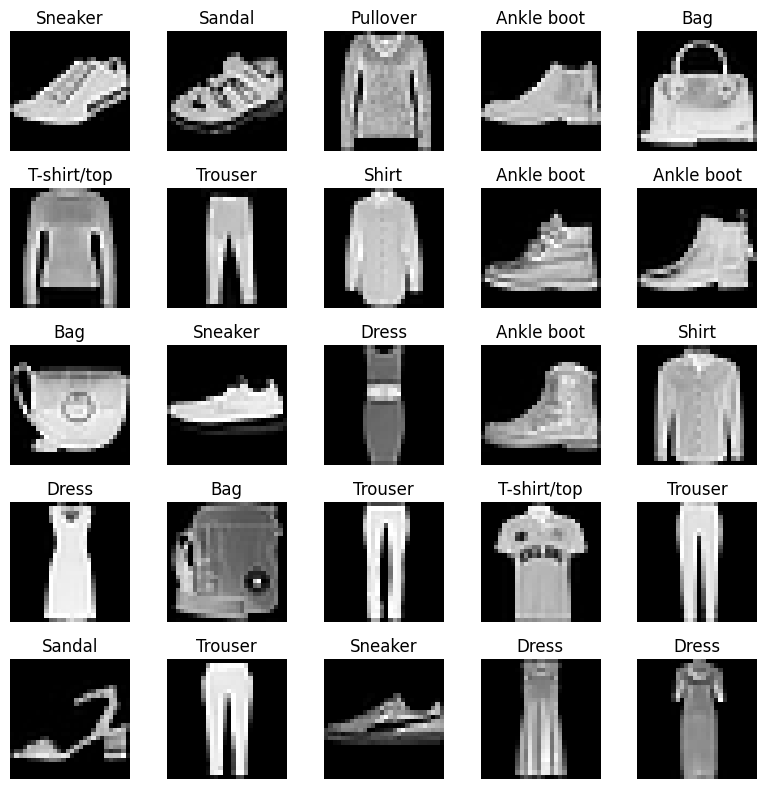

time: 2.56 s (started: 2025-01-23 01:56:51 +00:00)


In [81]:
# np.random.seed(42)
sample = np.random.randint(60000, size=25)

fig = plt.figure(figsize=(8, 8))
for i, idx in enumerate(sample):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.axis('off')
    plt.title(columns[y_train[idx]])
fig.tight_layout()
plt.show()

In [82]:
pd.Series(y_train).value_counts().sort_index()

,count
0,6000
1,6000
2,6000
3,6000
4,6000
5,6000
6,6000
7,6000
8,6000
9,6000


time: 13.1 ms (started: 2025-01-23 01:56:53 +00:00)


### Split: the training and validation.

In [83]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((48000, 28, 28), (12000, 28, 28), (48000,), (12000,))

time: 35.8 ms (started: 2025-01-23 01:56:53 +00:00)


# Data preprocessing

### Min-Max Scaling

In [84]:
X_train_s = X_train / 255.
X_val_s = X_val / 255.

X_train_s = X_train_s.reshape(-1, 28, 28, 1)
X_val_s = X_val_s.reshape(-1, 28, 28, 1)

X_train_s.shape, X_val_s.shape

((48000, 28, 28, 1), (12000, 28, 28, 1))

time: 153 ms (started: 2025-01-23 01:56:53 +00:00)


### One-Hot Encoding

In [85]:
y_train_o = to_categorical(y_train)
y_val_o = to_categorical(y_val)

y_train_o.shape, y_val_o.shape

((48000, 10), (12000, 10))

time: 5.63 ms (started: 2025-01-23 01:56:54 +00:00)


# Model: CNN

### Create model

In [86]:
from keras import layers

model = keras.Sequential([
    layers.Conv2D(filters=16, kernel_size=3, activation='relu',
                  input_shape=(28, 28, 1)),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Conv2D(filters=32, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 26, 26, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 13, 13, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 13, 13, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 11, 11, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 800)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         102,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 108,618 (424.29 KB)

 Trainable params: 108,618 (424.29 KB)

 Non-trainable params: 0 (0.00 B)

time: 105 ms (started: 2025-01-23 01:56:54 +00:00)


### Visualize the model architecture

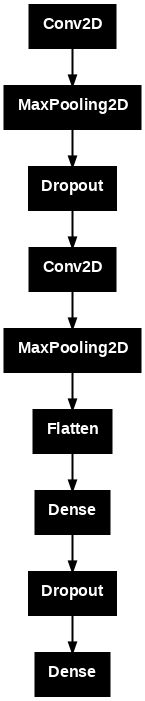

time: 83.7 ms (started: 2025-01-23 01:56:54 +00:00)


In [87]:
keras.utils.plot_model(model, dpi=72)

### Compile model

In [88]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=['accuracy'])

time: 6.25 ms (started: 2025-01-23 01:56:54 +00:00)


### History

In [89]:
EPOCHS = 30
BATCH_SIZE = 32

history = model.fit(X_train_s, y_train_o,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_val_s, y_val_o))


Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.7078 - loss: 0.7924 - val_accuracy: 0.8576 - val_loss: 0.3934
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8490 - loss: 0.4084 - val_accuracy: 0.8622 - val_loss: 0.3667
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8702 - loss: 0.3523 - val_accuracy: 0.8892 - val_loss: 0.2983
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8826 - loss: 0.3144 - val_accuracy: 0.8926 - val_loss: 0.2928
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8950 - loss: 0.2878 - val_accuracy: 0.8972 - val_loss: 0.2819
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8999 - loss: 0.2717 - val_accuracy: 0.9019 - val_loss: 0.2640
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9027 - loss: 0.2589 - val_accuracy: 0.9067 - val_loss: 0.2537
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9053 - loss: 0.2547 

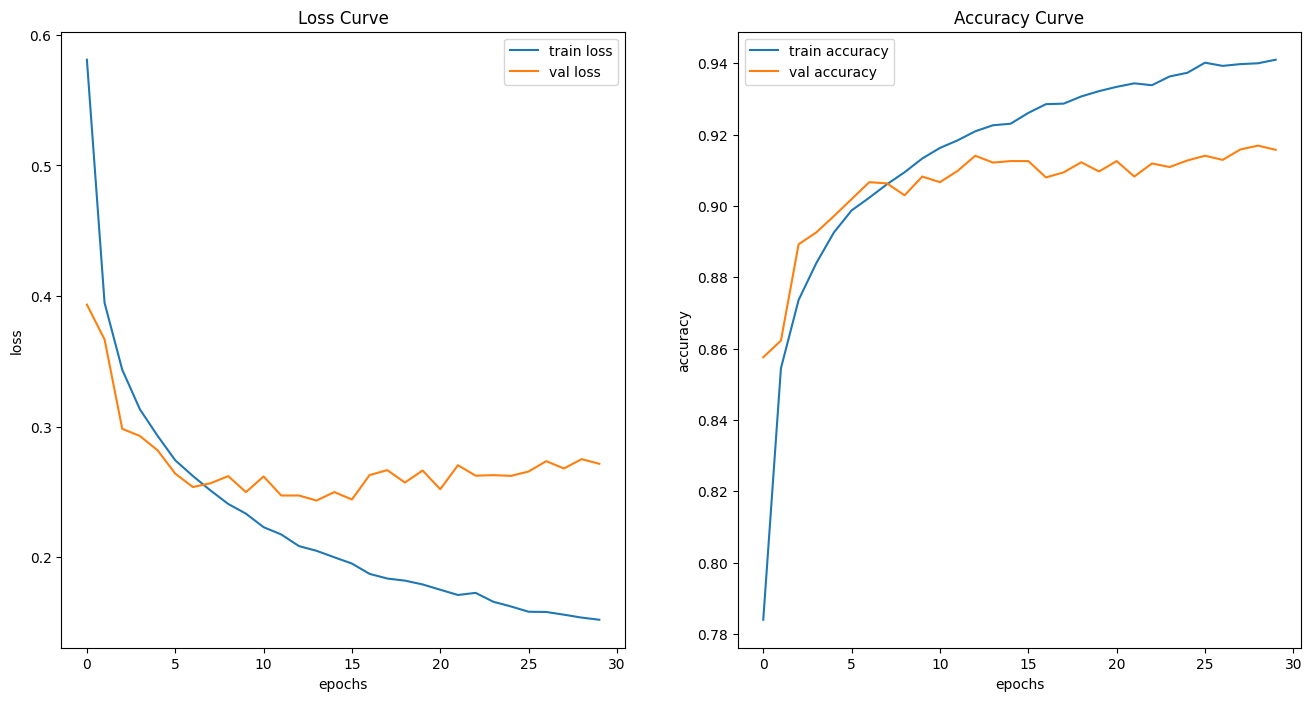

time: 309 ms (started: 2025-01-23 01:59:31 +00:00)


In [90]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.plot(hist['epoch'], hist['loss'], label='train loss')
    plt.plot(hist['epoch'], hist['val_loss'], label='val loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.plot(hist['epoch'], hist['accuracy'], label='train accuracy')
    plt.plot(hist['epoch'], hist['val_accuracy'], label='val accuracy')
    plt.title('Accuracy Curve')
    plt.legend()
    plt.show()

plot_history(history)

# Evaluate

### One-hot Encoding

In [91]:
X_test_s = X_test / 255.
X_test_s = X_test_s.reshape(-1, 28, 28, 1)
y_test_o = to_categorical(y_test)

time: 28.4 ms (started: 2025-01-23 01:59:32 +00:00)


### Get prediction

In [92]:
y_pred = model.predict(X_test_s)

y_pred = np.argmax(y_pred, axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([9, 2, 1, ..., 8, 1, 5])

time: 1.38 s (started: 2025-01-23 01:59:32 +00:00)


accuracy: 0.9104
recall: 0.9103999999999998
precision: 0.9103707792279749
f1 : 0.9102093691452255


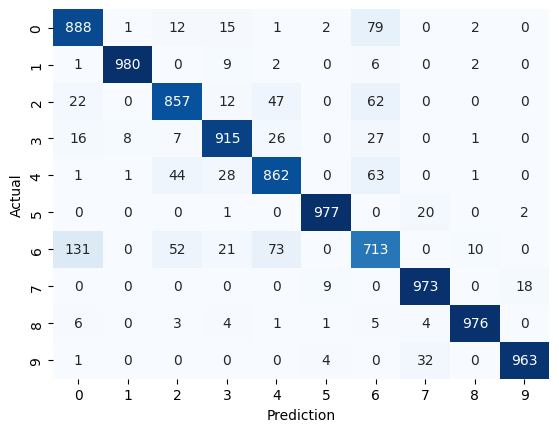

time: 365 ms (started: 2025-01-23 01:59:33 +00:00)


In [93]:
# Define a function to print metrics and display the confusion matrix
def print_metrics(y_true, y_pred, aver='binary'):
    print('accuracy:', accuracy_score(y_true, y_pred))
    print('recall:', recall_score(y_true, y_pred, average=aver))
    print('precision:', precision_score(y_true, y_pred, average=aver))
    print('f1 :', f1_score(y_true, y_pred, average=aver))

    # Plot the confusion matrix
    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

# Print metrics for the test dataset
print_metrics(y_test, y_pred, aver='macro')


# Save model
- loaded_model = keras.saving.load_model('model_path')
- loaded_model.summary()

In [94]:
model.save('cnn_muti_fashion.h5')

time: 45.6 ms (started: 2025-01-23 01:59:34 +00:00)


In [95]:
model.save('cnn_muti_fashion.keras')

time: 40.6 ms (started: 2025-01-23 01:59:34 +00:00)


In [96]:
# model.save('cnn_muti_fashion')

time: 209 µs (started: 2025-01-23 01:59:34 +00:00)
